###  Implemention of  Hyperparameter Tuning using GridSearchCV / RandomizedSearchCV, we will be using fake news dataset for this project

Step 1: Importing all the required libraries.

In [10]:
# Core Libraries
import pandas as pd
import numpy as np
import re
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

# NLP libraries and tools
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# preprocessing and modeling
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

# Metrics and evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

#remove warnings
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Saif Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Step 2: Uploading the dataset.


First 5 rows of dataset:
                                                Text label
0   Top Trump Surrogate BRUTALLY Stabs Him In The...  Fake
1  U.S. conservative leader optimistic of common ...  Real
2  Trump proposes U.S. tax overhaul, stirs concer...  Real
3   Court Forces Ohio To Allow Millions Of Illega...  Fake
4  Democrats say Trump agrees to work on immigrat...  Real

Label Distribution:
label
Fake    5000
Real    4900
Name: count, dtype: int64


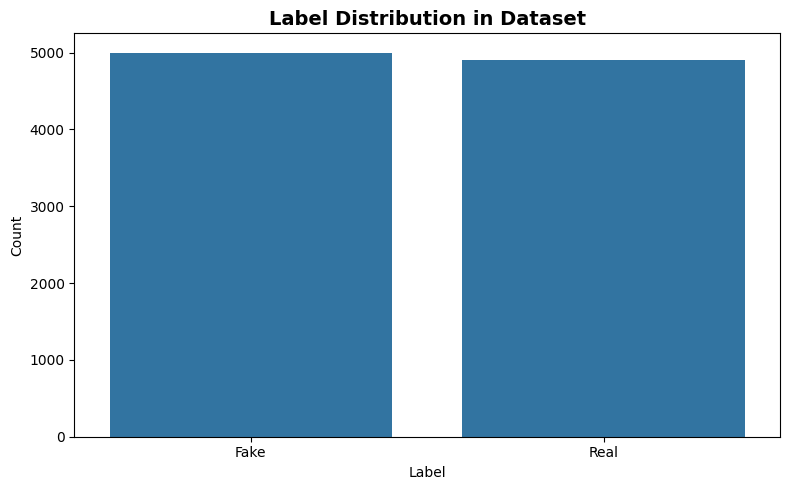

In [11]:
# Function to load and explore the dataset
def load_dataset(file_path):
    """
    Load and perform initial exploration of the dataset
    """
    # upload the dataset
    df = pd.read_csv(file_path)
    
    #check the first few rows of the dataset
    print("First 5 rows of dataset:")
    print(df.head())
    
    # check the label distribution
    print("\nLabel Distribution:")
    print(df['label'].value_counts())
    
    # plot the label distribution with default colors
    plt.figure(figsize=(8, 5))
    sns.countplot(x='label', data=df)
    plt.title('Label Distribution in Dataset', fontsize=14, fontweight='bold')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('figures/label_distribution.png')
    plt.show()
    
    return df

# Load dataset
df = load_dataset('news_dataset.csv')

Step 3: Cleaning the data by removing missing and duolicated values.

Missing Values:
Text     0
label    0
dtype: int64

Missing Values After Cleaning:
Text     0
label    0
dtype: int64

Duplicate rows found: 35
Duplicates after removal: 0

First 5 rows after cleaning:
                                                Text label
0   Top Trump Surrogate BRUTALLY Stabs Him In The...  Fake
1  U.S. conservative leader optimistic of common ...  Real
2  Trump proposes U.S. tax overhaul, stirs concer...  Real
3   Court Forces Ohio To Allow Millions Of Illega...  Fake
4  Democrats say Trump agrees to work on immigrat...  Real


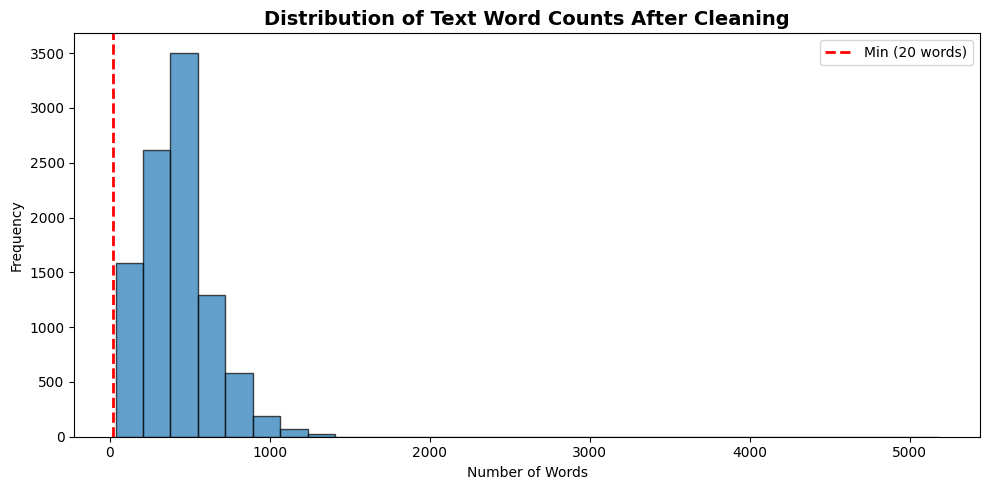

In [12]:
# perform data cleaning before preprocessing and training the models
def clean_dataset(df):
    """
    Clean the dataset by handling missing values, duplicates, and filtering reviews
    """
    # checking for missing values
    print("Missing Values:")
    print(df.isnull().sum())
    
    # since we got some missing values in the Text column, we will drop those rows
    df.dropna(subset=['Text'], inplace=True)
    
    #again check for missing values
    print("\nMissing Values After Cleaning:")
    print(df.isnull().sum())
    
    #checking for duplicates
    print(f"\nDuplicate rows found: {df.duplicated().sum()}")
    
    #we also got some duplicate rows, we will drop those as well
    df.drop_duplicates(inplace=True)
    
    #again check for duplicates
    print(f"Duplicates after removal: {df.duplicated().sum()}")
    
    #checking the head of the dataset after preprocessing
    print("\nFirst 5 rows after cleaning:")
    print(df.head())
    
    # Visualize Text length distribution after cleaning
    plt.figure(figsize=(10, 5))
    plt.hist(df['Text'].apply(lambda x: len(str(x).split())), bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(x=20, color='red', linestyle='--', linewidth=2, label='Min (20 words)')
    plt.title('Distribution of Text Word Counts After Cleaning', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.savefig('figures/Text_length_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return df

# Clean dataset (before preprocessing)
df = clean_dataset(df)

Step 4: Preprocessing the data

In [13]:
# preprocess the text data using advance text cleaning techniques to improve the performance of the models
# Load stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Advanced NLP preprocessing pipeline:
    - Lowercasing
    - Remove URLs and HTML tags
    - Normalize currency and numbers
    - Remove special characters
    - Tokenization (NLTK)
    - POS tagging
    - Lemmatization with POS
    - Stopword removal
    - Remove short tokens
    - Clean extra spaces
    """
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    # 3. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # 4. Normalize currency (e.g., $100.50 → money)
    text = re.sub(r'\$\s?\d+(\.\d+)?', ' money ', text)
    
    # 5. Normalize numbers (e.g., 123 → number)
    text = re.sub(r'\d+(\.\d+)?', ' number ', text)
    
    # 6. Remove special characters & punctuation
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # 7. Tokenization using NLTK
    tokens = word_tokenize(text)
    
    # 8. POS tagging
    pos_tags = pos_tag(tokens)
    
    # 9. Helper function for POS conversion (inside function as requested)
    def get_wordnet_pos(tag):
        if tag.startswith('J'):
            return 'a'  # adjective
        elif tag.startswith('V'):
            return 'v'  # verb
        elif tag.startswith('N'):
            return 'n'  # noun
        elif tag.startswith('R'):
            return 'r'  # adverb
        else:
            return 'n'
    
    # 10. Lemmatization + stopword removal + short word filtering
    cleaned_words = []
    for word, tag in pos_tags:
        if word not in stop_words and len(word) > 2:
            pos = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word, pos)
            cleaned_words.append(lemma)
    
    # 11. Join tokens
    text = ' '.join(cleaned_words)
    
    # 12. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


# apply the preprocessing function to the reviews
print("Applying text preprocessing...")
df['Text'] = df['Text'].apply(preprocess_text)

# Remove any empty strings after preprocessing
df = df[df['Text'] != ""]

# check the length and sample of the dataset after preprocessing
print("Text preprocessing completed!")
print(f"Number of reviews after preprocessing: {len(df)}")
print("\nSample preprocessed text:")
print(df['Text'].iloc[0][:200] + "...")

Applying text preprocessing...
Text preprocessing completed!
Number of reviews after preprocessing: 9865

Sample preprocessed text:
top trump surrogate brutally stab back pathetic video look though republican presidential candidate donald trump lose support even within rank know thing get bad even top surrogate start turn exactly ...


Step 5: Feature Engineering, splitting data into target and features, applying label encoder  and train test splitting the data.

In [14]:
# Prepare features using TF-IDF and labels using LabelEncoder
def prepare_features(df):
    """
    Prepare features using TF-IDF and labels using LabelEncoder
    """
    # now we will split the dataset into features and target variable
    X = df['Text']  # Features (Text)
    y = df['label']  # Target variable (label)
    
    # we will convert the target variable into numerical format using LabelEncoder and save the encoder for later use
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    
    # lets see the mapping of the labels
    label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
    print("Label Mapping:", label_mapping)
    
    # checking the shape of the features and target variable
    print("Features shape:", X.shape)
    print("Target variable shape:", y_encoded.shape)
    
    # train test split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
    
    print(f"\nTraining set size: {X_train.shape}")
    print(f"Test set size: {X_test.shape}")
    
    return X_train, X_test, y_train, y_test, label_encoder

# Prepare features
X_train, X_test, y_train, y_test, label_encoder = prepare_features(df)

Label Mapping: {'Fake': 0, 'Real': 1}
Features shape: (9865,)
Target variable shape: (9865,)

Training set size: (7892,)
Test set size: (1973,)


Step 6: Creating Baseline model and confuion matrix


 BASELINE MODEL
Accuracy: 0.9934 (99.34%)

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      1000
        Real       0.99      0.99      0.99       973

    accuracy                           0.99      1973
   macro avg       0.99      0.99      0.99      1973
weighted avg       0.99      0.99      0.99      1973



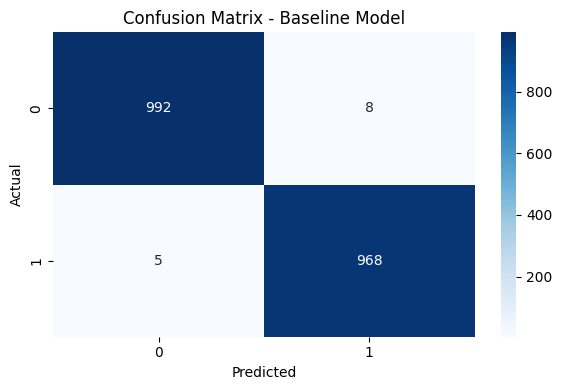

In [15]:
# Baseline model function that trains a Logistic Regression model, evaluates it, and plots the confusion matrix

def baseline_model(X_train, y_train, X_test, y_test):
    print("\n" + "="*60)
    print(" BASELINE MODEL")
    print("="*60)
    
    baseline_pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf', LogisticRegression(max_iter=1000))
    ])
    
    baseline_pipe.fit(X_train, y_train)
    baseline_preds = baseline_pipe.predict(X_test)
    baseline_acc = accuracy_score(y_test, baseline_preds)
    
    print(f"Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
    print("\nClassification Report:")
    print(classification_report(y_test, baseline_preds, target_names=['Fake', 'Real']))
    
    # Confusion Matrix for Baseline Model
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, baseline_preds), annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix - Baseline Model")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig('figures/confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return baseline_pipe, baseline_acc, baseline_preds

baseline_model, baseline_acc, baseline_preds = baseline_model(X_train, y_train, X_test, y_test)

Step 7: Grid search CV function and confusion matrix.


 GRIDSEARCH CV MODEL
Training GridSearchCV...
Best Params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}
Accuracy: 0.9970 (99.70%)
Time: 78.4867 seconds

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      1000
        Real       1.00      1.00      1.00       973

    accuracy                           1.00      1973
   macro avg       1.00      1.00      1.00      1973
weighted avg       1.00      1.00      1.00      1973



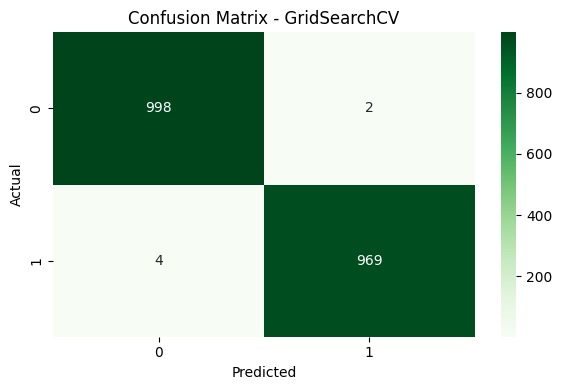

In [16]:
# Grid Search CV Model with hyperparameter tuning, training, evaluation, and confusion matrix plotting

def gridsearchcv_model(X_train, y_train, X_test, y_test):
    print("\n" + "="*60)
    print(" GRIDSEARCH CV MODEL")
    print("="*60)
    
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', LogisticRegression(max_iter=1000))
    ])
    
    grid_params = {
        'tfidf__max_features': [3000, 5000],
        'tfidf__ngram_range': [(1,1), (1,2)],
        'clf__C': [0.1, 1, 10],
        'clf__solver': ['liblinear', 'lbfgs'],
        'clf__penalty': ['l2']
    }
    
    grid = GridSearchCV(pipeline, grid_params, cv=3, n_jobs=-1)
    
    start = time.time()
    print("Training GridSearchCV...")
    grid.fit(X_train, y_train)
    grid_time = time.time() - start
    
    grid_preds = grid.predict(X_test)
    grid_acc = accuracy_score(y_test, grid_preds)
    
    print(f"Best Params: {grid.best_params_}")
    print(f"Accuracy: {grid_acc:.4f} ({grid_acc*100:.2f}%)")
    print(f"Time: {grid_time:.4f} seconds")
    print("\nClassification Report:")
    print(classification_report(y_test, grid_preds, target_names=['Fake', 'Real']))
    
    # Confusion Matrix for GridSearchCV
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, grid_preds), annot=True, fmt='d', cmap='Greens')
    plt.title("Confusion Matrix - GridSearchCV")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig('figures/confusion_matrix_gridsearch.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return grid, grid_acc, grid_preds, grid_time

grid_model, grid_acc, grid_preds, grid_time = gridsearchcv_model(X_train, y_train, X_test, y_test)

Step 8: Randomized Search CV function and its confusion matrix.


 RANDOMIZEDSEARCH CV MODEL
Training RandomizedSearchCV...
Best Params: {'tfidf__ngram_range': (1, 2), 'tfidf__max_features': 3000, 'clf__solver': 'lbfgs', 'clf__penalty': 'l2', 'clf__C': 7.933103448275862}
Accuracy: 0.9970 (99.70%)
Time: 27.1474 seconds

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      1000
        Real       1.00      1.00      1.00       973

    accuracy                           1.00      1973
   macro avg       1.00      1.00      1.00      1973
weighted avg       1.00      1.00      1.00      1973



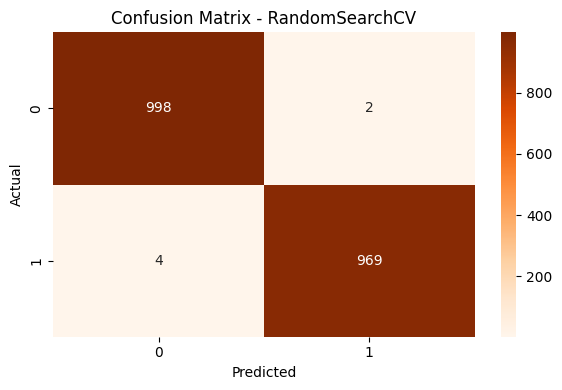

In [17]:
# Randomized Search CV Model with hyperparameter tuning, training, evaluation, and confusion matrix plotting

def randomsearchcv_model(X_train, y_train, X_test, y_test):
    print("\n" + "="*60)
    print(" RANDOMIZEDSEARCH CV MODEL")
    print("="*60)
    
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', LogisticRegression(max_iter=1000))
    ])
    
    random_params = {
        'tfidf__max_features': [2000, 3000, 5000],
        'tfidf__ngram_range': [(1,1), (1,2)],
        'clf__C': np.linspace(0.01, 10, 30),
        'clf__solver': ['liblinear', 'lbfgs'],
        'clf__penalty': ['l2']
    }
    
    random = RandomizedSearchCV(pipeline, random_params, n_iter=10, cv=3, random_state=42, n_jobs=-1)
    
    start = time.time()
    print("Training RandomizedSearchCV...")
    random.fit(X_train, y_train)
    random_time = time.time() - start
    
    random_preds = random.predict(X_test)
    random_acc = accuracy_score(y_test, random_preds)
    
    print(f"Best Params: {random.best_params_}")
    print(f"Accuracy: {random_acc:.4f} ({random_acc*100:.2f}%)")
    print(f"Time: {random_time:.4f} seconds")
    print("\nClassification Report:")
    print(classification_report(y_test, random_preds, target_names=['Fake', 'Real']))
    
    # Confusion Matrix for RandomSearchCV
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, random_preds), annot=True, fmt='d', cmap='Oranges')
    plt.title("Confusion Matrix - RandomSearchCV")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig('figures/confusion_matrix_randomsearch.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return random, random_acc, random_preds, random_time

random_model, random_acc, random_preds, random_time = randomsearchcv_model(X_train, y_train, X_test, y_test)

Step 9: Comparison tables and graphs of both the models.


===== MODEL COMPARISON =====
          Model  Accuracy
0      Baseline  0.993411
1    GridSearch  0.996959
2  RandomSearch  0.996959


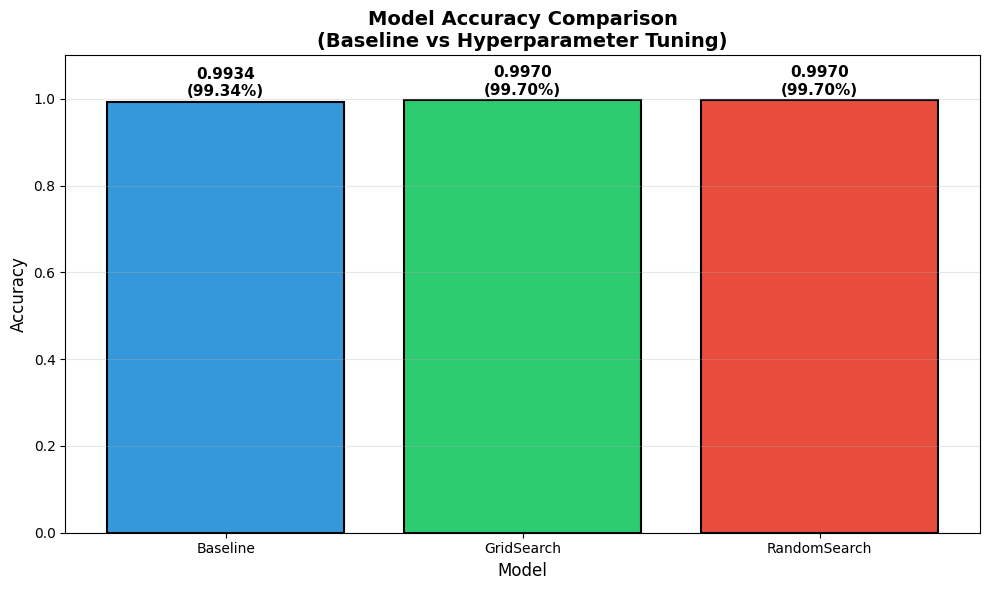

✅ Accuracy comparison plot saved to 'figures/accuracy_comparison.png'


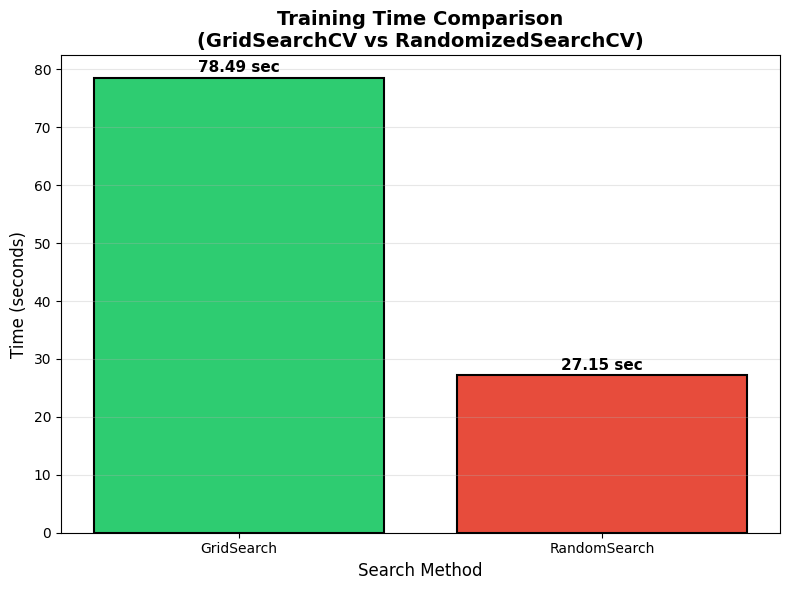

✅ Training time comparison plot saved to 'figures/training_time_comparison.png'

⏱️ GridSearchCV took: 78.49 seconds
⏱️ RandomizedSearchCV took: 27.15 seconds
⚡ RandomizedSearchCV was 2.89x faster!


In [18]:
# Create comparison table for all three models and plot accuracy and training time comparisons

def create_comparison_table(baseline_acc, grid_acc, random_acc):
    """
    Create comparison table for all three models
    """
    comparison_df = pd.DataFrame({
        "Model": ["Baseline", "GridSearch", "RandomSearch"],
        "Accuracy": [baseline_acc, grid_acc, random_acc]
    })
    
    print("\n===== MODEL COMPARISON =====")
    print(comparison_df)
    
    return comparison_df

def plot_accuracy_comparison(comparison_df):
    """
    Plot accuracy comparison bar chart and save to figures folder
    """
    plt.figure(figsize=(10, 6))
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    bars = plt.bar(comparison_df["Model"], comparison_df["Accuracy"], 
                   color=colors, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar, acc in zip(bars, comparison_df["Accuracy"]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{acc:.4f}\n({acc*100:.2f}%)', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.title("Model Accuracy Comparison\n(Baseline vs Hyperparameter Tuning)", 
              fontsize=14, fontweight='bold')
    plt.xlabel("Model", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.ylim(0, 1.1)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('figures/accuracy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Accuracy comparison plot saved to 'figures/accuracy_comparison.png'")

def plot_training_time_comparison(grid_time, random_time):
    """
    Plot training time comparison bar chart and save to figures folder
    """
    time_df = pd.DataFrame({
        "Model": ["GridSearch", "RandomSearch"],
        "Time": [grid_time, random_time]
    })
    
    plt.figure(figsize=(8, 6))
    colors = ['#2ecc71', '#e74c3c']
    bars = plt.bar(time_df["Model"], time_df["Time"], 
                   color=colors, edgecolor='black', linewidth=1.5)
    
    # Add time labels
    for bar, t in zip(bars, time_df["Time"]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{t:.2f} sec', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.title("Training Time Comparison\n(GridSearchCV vs RandomizedSearchCV)", 
              fontsize=14, fontweight='bold')
    plt.xlabel("Search Method", fontsize=12)
    plt.ylabel("Time (seconds)", fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('figures/training_time_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Training time comparison plot saved to 'figures/training_time_comparison.png'")
    
    # Print time statistics
    print(f"\n⏱️ GridSearchCV took: {grid_time:.2f} seconds")
    print(f"⏱️ RandomizedSearchCV took: {random_time:.2f} seconds")
    print(f"⚡ RandomizedSearchCV was {grid_time/random_time:.2f}x faster!")

# Execute Cell 10 functions
comparison_df = create_comparison_table(baseline_acc, grid_acc, random_acc)
plot_accuracy_comparison(comparison_df)
plot_training_time_comparison(grid_time, random_time)

Step 10: Performance improvement function.

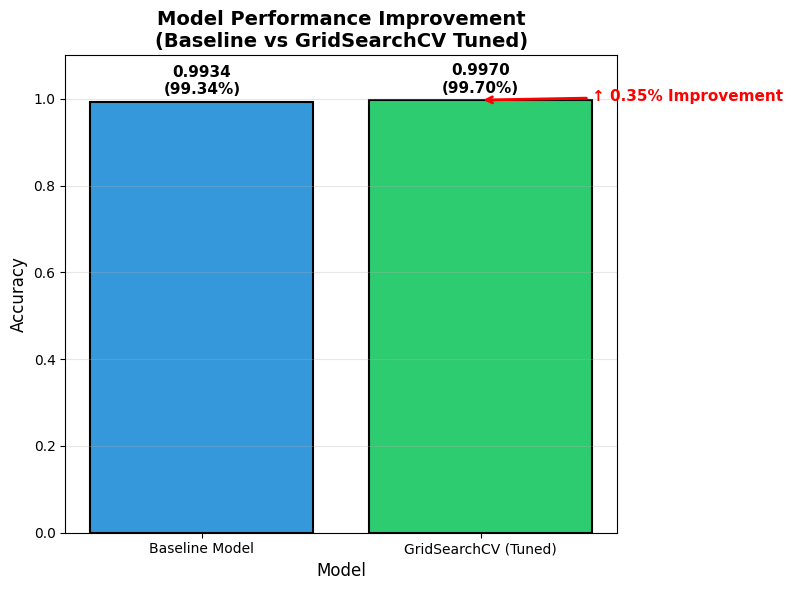

✅ Performance improvement plot saved to 'figures/performance_improvement.png'

📈 Performance Improvement: 0.35%
📊 Baseline Accuracy: 0.9934 (99.34%)
🎯 Tuned Accuracy: 0.9970 (99.70%)


In [31]:
# performance improvement plot from baseline to best tuned model with arrow annotation and percentage improvement

def plot_performance_improvement(baseline_acc, grid_acc, random_acc, grid_model, random_model):
    """
    Plot performance improvement from baseline to best tuned model
    """
    # Determine best model
    if grid_acc >= random_acc:
        best_model_name = "GridSearchCV"
        best_acc = grid_acc
        best_params = grid_model.best_params_
    else:
        best_model_name = "RandomizedSearchCV"
        best_acc = random_acc
        best_params = random_model.best_params_
    
    # Create improvement plot
    plt.figure(figsize=(8, 6))
    categories = ['Baseline Model', f'{best_model_name} (Tuned)']
    accuracies = [baseline_acc, best_acc]
    colors = ['#3498db', '#2ecc71']
    
    bars = plt.bar(categories, accuracies, color=colors, edgecolor='black', linewidth=1.5)
    
    # Add value labels
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.010,
                 f'{acc:.4f}\n({acc*100:.2f}%)', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Calculate improvement
    improvement = (best_acc - baseline_acc) * 100
    
    # Add arrow annotation
    plt.annotate(f'↑ {improvement:.2f}% Improvement', 
                 xy=(1, best_acc), 
                 xytext=(1.4, (baseline_acc + best_acc)/2),
                 arrowprops=dict(arrowstyle='->', color='red', lw=2),
                 fontsize=11, color='red', fontweight='bold')
    
    plt.title(f'Model Performance Improvement\n(Baseline vs {best_model_name} Tuned)', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Model', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1.1)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('figures/performance_improvement.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✅ Performance improvement plot saved to 'figures/performance_improvement.png'")
    print(f"\n📈 Performance Improvement: {improvement:.2f}%")
    print(f"📊 Baseline Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
    print(f"🎯 Tuned Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
    
    return best_model_name, best_acc, best_params, improvement

# Execute Cell 11 function
best_model_name, best_acc, best_params, improvement = plot_performance_improvement(
    baseline_acc, grid_acc, random_acc, grid_model, random_model
)

Step 11: Saving the models.

In [32]:
# Function to save the best performing model to models folder

def save_best_model(grid_model, random_model, grid_acc, random_acc, label_encoder):
    """
    Save the best performing model and label encoder to models folder
    
    Parameters:
    - grid_model: Trained GridSearchCV model
    - random_model: Trained RandomizedSearchCV model  
    - grid_acc: Accuracy of GridSearchCV model
    - random_acc: Accuracy of RandomizedSearchCV model
    - label_encoder: Label encoder used for transforming labels
    
    Returns:
    - best_model: The best performing model
    - best_method: Name of the best method ('GridSearchCV' or 'RandomizedSearchCV')
    - best_accuracy: Accuracy of the best model
    """
    # Determine which model performs better
    if grid_acc >= random_acc:
        best_model = grid_model.best_estimator_
        best_method = "GridSearchCV"
        best_accuracy = grid_acc
        best_params = grid_model.best_params_
    else:
        best_model = random_model.best_estimator_
        best_method = "RandomizedSearchCV"
        best_accuracy = random_acc
        best_params = random_model.best_params_
    
    # Save the best model
    with open("models/best_model.pkl", "wb") as f:
        pickle.dump(best_model, f)
    
    # Save the label encoder (important for converting predictions back to original labels)
    with open("models/label_encoder.pkl", "wb") as f:
        pickle.dump(label_encoder, f)
    
    # Save the best parameters for reference
    with open("models/best_params.txt", "w") as f:
        f.write(f"Best Method: {best_method}\n")
        f.write(f"Best Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)\n")
        f.write(f"Best Parameters: {best_params}\n")
    
    print("\n" + "="*50)
    print(" MODEL SAVING")
    print("="*50)
    print(f"✅ Best model saved to 'models/best_model.pkl'")
    print(f"✅ Label encoder saved to 'models/label_encoder.pkl'")
    print(f"✅ Best parameters saved to 'models/best_params.txt'")
    print(f"\n🏆 Best model from: {best_method}")
    print(f"📌 Best parameters: {best_params}")
    print(f"🎯 Best accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
    
    return best_model, best_method, best_accuracy, best_params

# Execute Cell 12 function - NOW INCLUDES label_encoder
best_model, best_method, best_accuracy, best_params = save_best_model(
    grid_model, random_model, grid_acc, random_acc, label_encoder
)


 MODEL SAVING
✅ Best model saved to 'models/best_model.pkl'
✅ Label encoder saved to 'models/label_encoder.pkl'
✅ Best parameters saved to 'models/best_params.txt'

🏆 Best model from: GridSearchCV
📌 Best parameters: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}
🎯 Best accuracy: 0.9970 (99.70%)


Step 12: Final summary of the best model

In [33]:
# Final summary function to display all results in a comprehensive manner

def display_final_summary(baseline_acc, grid_acc, random_acc, grid_time, random_time, 
                          best_params, best_model_name, best_acc):
    """
    Display comprehensive final summary of all results
    """
    print("\n" + "="*60)
    print(" FINAL RESULTS SUMMARY")
    print("="*60)
    
    print(f"\n🏆 BEST MODEL: {best_model_name}")
    print(f"📌 Best Parameters: {best_params}")
    print(f"🎯 Best Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
    
    print(f"\n📊 PERFORMANCE COMPARISON:")
    print(f"   Before Tuning Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
    print(f"   After Tuning Accuracy:  {best_acc:.4f} ({best_acc*100:.2f}%)")
    print(f"   Improvement: {(best_acc - baseline_acc)*100:.2f}%")
    
    print(f"\n⏱️ TRAINING TIMES:")
    print(f"   GridSearchCV: {grid_time:.2f} seconds")
    print(f"   RandomizedSearchCV: {random_time:.2f} seconds")
    print(f"   Speed difference: {grid_time/random_time:.2f}x faster with RandomSearch")
    
    print(f"\n📁 SAVED FILES:")
    print(f"   Models saved in 'models/' folder")
    print(f"   - label_encoder.pkl")
    print(f"   - best_model.pkl")
    print(f"\n   Figures saved in 'figures/' folder:")
    print(f"   - label_distribution.png")
    print(f"   - Text_length_distribution.png")
    print(f"   - most_common_words.png")
    print(f"   - confusion_matrix_baseline.png")
    print(f"   - confusion_matrix_gridsearch.png")
    print(f"   - confusion_matrix_randomsearch.png")
    print(f"   - accuracy_comparison.png")
    print(f"   - training_time_comparison.png")
    print(f"   - performance_improvement.png")
    
    return True

# Execute Cell 13 function
display_final_summary(baseline_acc, grid_acc, random_acc, grid_time, random_time, 
                      best_params, best_model_name, best_acc)


 FINAL RESULTS SUMMARY

🏆 BEST MODEL: GridSearchCV
📌 Best Parameters: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}
🎯 Best Accuracy: 0.9970 (99.70%)

📊 PERFORMANCE COMPARISON:
   Before Tuning Accuracy: 0.9934 (99.34%)
   After Tuning Accuracy:  0.9970 (99.70%)
   Improvement: 0.35%

⏱️ TRAINING TIMES:
   GridSearchCV: 78.49 seconds
   RandomizedSearchCV: 27.15 seconds
   Speed difference: 2.89x faster with RandomSearch

📁 SAVED FILES:
   Models saved in 'models/' folder
   - label_encoder.pkl
   - best_model.pkl

   Figures saved in 'figures/' folder:
   - label_distribution.png
   - Text_length_distribution.png
   - most_common_words.png
   - confusion_matrix_baseline.png
   - confusion_matrix_gridsearch.png
   - confusion_matrix_randomsearch.png
   - accuracy_comparison.png
   - training_time_comparison.png
   - performance_improvement.png


True

Step 13: Prediction System.


 PREDICTION SYSTEM

----------------------------------------

🔍 Analyzing text...
📄 Original text preview: trump attacked pakistan...

🎯 Prediction (Tuned Model): Fake
📊 Confidence: 69.89%
   Confidence Level: 🟡 Medium


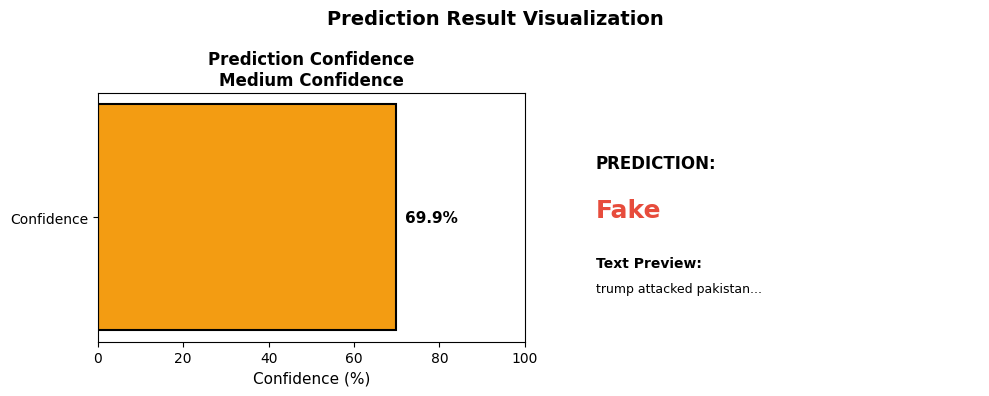

✅ Prediction visualization saved to 'figures/latest_prediction.png'

----------------------------------------

👋 Exiting prediction system. Goodbye!


In [35]:
# Function to preprocess single text input for prediction

def preprocess_single_text(text):
    """
    Preprocess a single text input for prediction
    """
    return preprocess_text(text)

def predict_single_text(model, label_encoder, text):
    """
    Make prediction on single text input
    """
    # Preprocess the text
    processed_text = preprocess_single_text(text)
    
    # Make prediction
    prediction = model.predict([processed_text])
    label = label_encoder.inverse_transform(prediction)
    
    # Get prediction probability if available
    confidence = None
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba([processed_text])[0]
        confidence = max(proba) * 100
    
    return label[0], confidence, processed_text

def visualize_prediction_result(text, label, confidence=None):
    """
    Create visualization for prediction result
    """
    plt.figure(figsize=(10, 4))
    
    # Subplot 1: Confidence gauge (if confidence available)
    if confidence:
        plt.subplot(1, 2, 1)
        
        # Determine color based on confidence
        if confidence >= 75:
            color = '#2ecc71'  # Green - High confidence
            level = "High"
        elif confidence >= 50:
            color = '#f39c12'  # Orange - Medium confidence
            level = "Medium"
        else:
            color = '#e74c3c'  # Red - Low confidence
            level = "Low"
        
        # Create horizontal bar for confidence
        bars = plt.barh(['Confidence'], [confidence], color=color, edgecolor='black', linewidth=1.5)
        plt.xlim(0, 100)
        plt.xlabel('Confidence (%)', fontsize=11)
        plt.title(f'Prediction Confidence\n{level} Confidence', fontsize=12, fontweight='bold')
        
        # Add value label
        plt.text(confidence + 2, 0, f'{confidence:.1f}%', va='center', fontsize=11, fontweight='bold')
        
        # Subplot 2: Prediction result
        plt.subplot(1, 2, 2)
        plt.axis('off')
        
        # Display prediction with color
        pred_color = '#2ecc71' if label == 'REAL' else '#e74c3c'
        plt.text(0.1, 0.7, f'PREDICTION:', fontsize=12, fontweight='bold')
        plt.text(0.1, 0.5, f'{label}', fontsize=18, fontweight='bold', color=pred_color)
        plt.text(0.1, 0.3, f'Text Preview:', fontsize=10, fontweight='bold')
        plt.text(0.1, 0.2, f'{text[:100]}...', fontsize=9, wrap=True)
        
    else:
        # Single plot for prediction without confidence
        plt.subplot(1, 1, 1)
        plt.axis('off')
        pred_color = '#2ecc71' if label == 'REAL' else '#e74c3c'
        plt.text(0.1, 0.7, f'PREDICTION:', fontsize=14, fontweight='bold')
        plt.text(0.1, 0.5, f'{label}', fontsize=20, fontweight='bold', color=pred_color)
        plt.text(0.1, 0.3, f'Text:', fontsize=12, fontweight='bold')
        plt.text(0.1, 0.15, f'{text[:150]}...', fontsize=10, wrap=True)
    
    plt.suptitle('Prediction Result Visualization', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/latest_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Prediction visualization saved to 'figures/latest_prediction.png'")

def run_prediction_system(model, label_encoder):
    """
    Interactive prediction system with loop
    """
    print("\n" + "="*60)
    print(" PREDICTION SYSTEM")
    print("="*60)
    
    while True:
        print("\n" + "-"*40)
        text = input("📝 Enter news text to classify (or 'quit' to exit): ")
        
        if text.lower() == 'quit':
            print("\n👋 Exiting prediction system. Goodbye!")
            break
        
        if len(text.strip()) == 0:
            print("⚠️ Please enter some text to classify!")
            continue
        
        # Make prediction
        label, confidence, processed_text = predict_single_text(model, label_encoder, text)
        
        # Display results
        print(f"\n🔍 Analyzing text...")
        print(f"📄 Original text preview: {text[:150]}...")
        print(f"\n🎯 Prediction (Tuned Model): {label}")
        
        if confidence:
            print(f"📊 Confidence: {confidence:.2f}%")
            # Show confidence level emoji
            if confidence >= 75:
                print(f"   Confidence Level: 🟢 High")
            elif confidence >= 50:
                print(f"   Confidence Level: 🟡 Medium")
            else:
                print(f"   Confidence Level: 🔴 Low")
        
        # Visualize result
        visualize_prediction_result(text, label, confidence)
        
        # Ask if user wants to continue
        print("\n" + "-"*40)
        continue_choice = input("Would you like to predict another text? (yes/no): ")
        if continue_choice.lower() != 'yes':
            print("\n👋 Exiting prediction system. Goodbye!")
            break

# Execute Cell 14 function
run_prediction_system(best_model, label_encoder)